1. Escolha e análise do dataset
2. Separação em treino/validação/teste
3. Definição e justificativa da arquitetura
4. Treinamento e ajuste de hiperparâmetros
5. Avaliação com métricas completas
6. Conclusão crítica (overfitting/underfitting)

In [ ]:
import random
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
    roc_auc_score,
    roc_curve,
    auc,
    )
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from torch.utils.data import DataLoader, TensorDataset

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device(
    "mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu"
 )
print(f"PyTorch: {torch.__version__}")
print(f"CUDA disponível: {torch.cuda.is_available()}")
print(f"Dispositivo em uso: {device}")

## 1) Escolha e análise do dataset

### Justificativa técnica
- O **BEED_DATA** é adequado para classificação multiclasse supervisionada em saúde, pois representa diferentes padrões de EEG relacionados a crises epilépticas.
- Problema resolvido: **identificação automática da classe de atividade cerebral** (saudável ou tipos de crise), útil para apoio à triagem clínica.
- Características principais informadas:
  - 8.000 instâncias (2.000 por classe)
  - 16 features (X1 a X16), inteiras, multivariadas
  - 4 classes (0, 1, 2, 3)
  - Sem valores ausentes
  - Tarefa: classificação

### Interpretação das classes
- 0: indivíduos saudáveis (controle)
- 1: crise generalizada
- 2: crise focal
- 3: eventos de crise (incluindo blink/staring)

In [ ]:
csv_path = Path("../datasets/BEED_Data.csv")
df = pd.read_csv(csv_path)

feature_cols = [f"X{i}" for i in range(1, 17)]
target_col = "y"

X = df[feature_cols].copy()
y = df[target_col].copy()

print("Shape total:", df.shape)
print("Nº de features:", X.shape[1])
print("Classes únicas:", sorted(y.unique().tolist()))
print("\nDistribuição global de classes:")
display(y.value_counts().sort_index().rename("count").to_frame())
display((y.value_counts(normalize=True).sort_index() * 100).rename("percent").to_frame().round(2))

plt.figure(figsize=(7, 3))
sns.countplot(x=y)
plt.title("Distribuição de classes no dataset completo")
plt.xlabel("Classe")
plt.ylabel("Quantidade")
plt.grid(axis="y", alpha=0.2)
plt.show()

## 2) Separação do dataset (treino/validação/teste)

### Estratégia adotada: 70/15/15
- **Treino (70%)**: volume suficiente para aprender padrões robustos.
- **Validação (15%)**: ajuste de hiperparâmetros e monitoramento de overfitting.
- **Teste (15%)**: avaliação final imparcial.

A divisão é estratificada para preservar a proporção de classes em cada subconjunto.

In [ ]:
# Primeiro split: 70% treino, 30% temporário
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    random_state=SEED,
    stratify=y,
 )

# Segundo split: o bloco temporário (30%) vira 15% validação e 15% teste
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp,
 )

def summarize_split(y_part, split_name):
    counts = y_part.value_counts().sort_index()
    perc = (y_part.value_counts(normalize=True).sort_index() * 100).round(2)
    out = pd.DataFrame({
        "split": split_name,
        "classe": counts.index,
        "count": counts.values,
        "percent": perc.values,
    })
    return out

split_summary = pd.concat([
    summarize_split(y_train, "treino"),
    summarize_split(y_val, "validacao"),
    summarize_split(y_test, "teste"),
], ignore_index=True)

print("Tamanhos:")
print(f"Treino: {len(X_train)} ({len(X_train)/len(df):.1%})")
print(f"Validação: {len(X_val)} ({len(X_val)/len(df):.1%})")
print(f"Teste: {len(X_test)} ({len(X_test)/len(df):.1%})")
display(split_summary)

pivot_counts = split_summary.pivot(index="classe", columns="split", values="count")
pivot_perc = split_summary.pivot(index="classe", columns="split", values="percent")

print("\nContagens por classe e split:")
display(pivot_counts)
print("Percentuais por classe e split:")
display(pivot_perc)

# Decisão sobre desbalanceamento
max_diff = (pivot_perc.max(axis=1) - pivot_perc.min(axis=1)).max()
print(f"Maior diferença percentual intra-classe entre splits: {max_diff:.2f} p.p.")
if max_diff <= 1.0:
    print("Conclusão: distribuição proporcional preservada; não é necessário oversampling/undersampling.")
else:
    print("Conclusão: diferença relevante detectada; considerar pesos de classe ou reamostragem.")

## 3) Arquitetura da rede neural e justificativas

### Arquitetura escolhida (MLP)
- Entrada: 16 neurônios (uma feature por canal EEG).
- Camadas ocultas: 128 e 64 neurônios.
- Ativação: **ReLU** (boa estabilidade e gradientes mais saudáveis em redes profundas).
- Regularização: **BatchNorm1d** + **Dropout(0.30)**.
- Saída: 4 neurônios com logits (CrossEntropyLoss aplica softmax internamente).

### Justificativas técnicas
- Duas camadas ocultas elevam a capacidade de modelar relações não lineares sem exagerar complexidade.
- BatchNorm reduz covariate shift interno e acelera convergência.
- Dropout reduz coadaptação e risco de overfitting.
- CrossEntropyLoss é apropriada para classificação multiclasse mutuamente exclusiva.

In [ ]:
# Padronização: ajuste com treino e aplicação em validação/teste (evita vazamento de dados)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_val_scaled = scaler.transform(X_val).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

y_train_np = y_train.values.astype(np.int64)
y_val_np = y_val.values.astype(np.int64)
y_test_np = y_test.values.astype(np.int64)

class EEGClassifier(nn.Module):
    def __init__(self, input_dim=16, hidden1=128, hidden2=64, dropout=0.30, n_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1),
            nn.BatchNorm1d(hidden1),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden1, hidden2),
            nn.BatchNorm1d(hidden2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden2, n_classes),
        )

    def forward(self, x):
        return self.net(x)


def make_loader(X_arr, y_arr, batch_size=64, shuffle=False):
    ds = TensorDataset(
        torch.tensor(X_arr, dtype=torch.float32),
        torch.tensor(y_arr, dtype=torch.long),
    )
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def run_epoch(model, loader, criterion, optimizer=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss, total_correct, total_samples = 0.0, 0, 0

    with torch.set_grad_enabled(train_mode):
        for xb, yb in loader:
            xb = xb.to(device)
            yb = yb.to(device)

            logits = model(xb)
            loss = criterion(logits, yb)

            if train_mode:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            preds = logits.argmax(dim=1)
            total_loss += loss.item() * xb.size(0)
            total_correct += (preds == yb).sum().item()
            total_samples += xb.size(0)

    return total_loss / total_samples, total_correct / total_samples

## 4) Treinamento do modelo e ajuste de hiperparâmetros

### Estratégia de ajuste
- Busca em grade pequena e objetiva para manter custo computacional realista.
- Hiperparâmetros avaliados com base no conjunto de validação:
  - `learning_rate`: [1e-3, 5e-4]
  - `batch_size`: [64, 128]
  - `dropout`: [0.20, 0.30]
- Critério de escolha: **menor validation loss** e boa validation accuracy.

### Justificativas
- `Adam`: convergência rápida e robusta para este tipo de dado tabular/EEG resumido.
- `ReduceLROnPlateau`: reduz LR quando validação estagna.
- `EarlyStopping` (paciência): evita sobreajuste e economiza treino.

In [5]:
def train_with_early_stopping(
    model,
    train_loader,
    val_loader,
    criterion,
    optimizer,
    max_epochs=80,
    patience=12,
    scheduler=None,
 ):
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_state = None
    best_val_loss = float("inf")
    patience_counter = 0

    for epoch in range(1, max_epochs + 1):
        train_loss, train_acc = run_epoch(model, train_loader, criterion, optimizer)
        val_loss, val_acc = run_epoch(model, val_loader, criterion)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if scheduler is not None:
            scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    return history, best_val_loss, epoch


grid = {
    "learning_rate": [1e-3, 5e-4],
    "batch_size": [64, 128],
    "dropout": [0.20, 0.30],
}

search_rows = []
criterion = nn.CrossEntropyLoss()

for lr in grid["learning_rate"]:
    for batch_size in grid["batch_size"]:
        for dropout in grid["dropout"]:
            torch.manual_seed(SEED)
            model = EEGClassifier(dropout=dropout).to(device)
            optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode="min", factor=0.5, patience=4
            )

            train_loader = make_loader(X_train_scaled, y_train_np, batch_size=batch_size, shuffle=True)
            val_loader = make_loader(X_val_scaled, y_val_np, batch_size=256, shuffle=False)

            history, best_val_loss, used_epochs = train_with_early_stopping(
                model=model,
                train_loader=train_loader,
                val_loader=val_loader,
                criterion=criterion,
                optimizer=optimizer,
                max_epochs=60,
                patience=10,
                scheduler=scheduler,
            )

            search_rows.append({
                "lr": lr,
                "batch_size": batch_size,
                "dropout": dropout,
                "best_val_loss": best_val_loss,
                "best_val_acc": max(history["val_acc"]),
                "epochs_executed": used_epochs,
            })

search_df = pd.DataFrame(search_rows).sort_values(["best_val_loss", "best_val_acc"], ascending=[True, False])
display(search_df)

best_cfg = search_df.iloc[0].to_dict()
print("Melhor configuração encontrada:")
print(best_cfg)

,lr,batch_size,dropout,best_val_loss,best_val_acc,epochs_executed
2,0.0010,128,0.2,0.167599,0.938333,60
0,0.0010,64,0.2,0.186337,0.936667,55
3,0.0010,128,0.3,0.189894,0.926667,60
6,0.0005,128,0.2,0.203852,0.924167,60
4,0.0005,64,0.2,0.214140,0.922500,60
1,0.0010,64,0.3,0.222296,0.924167,55
7,0.0005,128,0.3,0.235548,0.909167,60
5,0.0005,64,0.3,0.247736,0.913333,60


Melhor configuração encontrada:
{'lr': 0.001, 'batch_size': 128.0, 'dropout': 0.2, 'best_val_loss': 0.16759927173455555, 'best_val_acc': 0.9383333333333334, 'epochs_executed': 60.0}


### Treinamento final com a melhor configuração (treino + validação monitorada)

O modelo abaixo é treinado no conjunto de treino e monitorado no conjunto de validação, mantendo o melhor estado por validation loss.

Treino final concluído em 22.73s
Épocas executadas: 120
Melhor val_loss: 0.1280
Train acc final: 0.9270
Val acc final: 0.9500


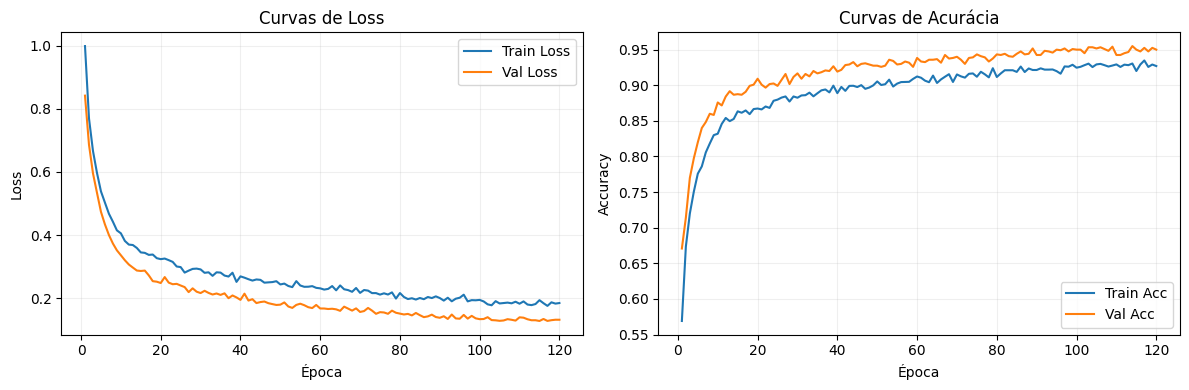

In [6]:
best_lr = float(best_cfg["lr"])
best_batch_size = int(best_cfg["batch_size"])
best_dropout = float(best_cfg["dropout"])

torch.manual_seed(SEED)
model = EEGClassifier(dropout=best_dropout).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=best_lr, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=5
)

train_loader = make_loader(X_train_scaled, y_train_np, batch_size=best_batch_size, shuffle=True)
val_loader = make_loader(X_val_scaled, y_val_np, batch_size=256, shuffle=False)

start_time = time.perf_counter()
history, best_val_loss, final_epoch = train_with_early_stopping(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    criterion=criterion,
    optimizer=optimizer,
    max_epochs=120,
    patience=15,
    scheduler=scheduler,
)
elapsed = time.perf_counter() - start_time

print(f"Treino final concluído em {elapsed:.2f}s")
print(f"Épocas executadas: {final_epoch}")
print(f"Melhor val_loss: {best_val_loss:.4f}")
print(f"Train acc final: {history['train_acc'][-1]:.4f}")
print(f"Val acc final: {history['val_acc'][-1]:.4f}")

epochs = range(1, len(history["train_loss"]) + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(epochs, history["train_loss"], label="Train Loss")
axes[0].plot(epochs, history["val_loss"], label="Val Loss")
axes[0].set_title("Curvas de Loss")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.2)
axes[0].legend()

axes[1].plot(epochs, history["train_acc"], label="Train Acc")
axes[1].plot(epochs, history["val_acc"], label="Val Acc")
axes[1].set_title("Curvas de Acurácia")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].grid(alpha=0.2)
axes[1].legend()

plt.tight_layout()
plt.show()

## 5) Avaliação com métricas no conjunto de teste

Métricas solicitadas:
- Acurácia
- Matriz de confusão
- Precisão, Revocação (Recall) e F1-score
- Curva ROC e AUC (multiclasse One-vs-Rest)

### Métrica principal escolhida: Acurácia
Como o cenário é de um dataset **perfeitamente balanceado** (exatamente 25% das amostras para cada uma das 4 classes, preservado na divisão), a Acurácia torna-se a métrica principal mais direta e confiável. Em cenários balanceados, ela não sofre do viés de uma classe majoritária, refletindo com exatidão a taxa global de acertos do modelo. O alto valor de acurácia obtido indica excelente adequação e capacidade de generalização.

Acurácia (teste - métrica principal): 0.9558
Precisão macro: 0.9569
Recall macro: 0.9558
F1 macro: 0.9560
F1 weighted: 0.9560

Relatório de classificação:
              precision    recall  f1-score   support

           0     1.0000    0.9967    0.9983       300
           1     0.9826    0.9400    0.9608       300
           2     0.9062    0.9667    0.9355       300
           3     0.9388    0.9200    0.9293       300

    accuracy                         0.9558      1200
   macro avg     0.9569    0.9558    0.9560      1200
weighted avg     0.9569    0.9558    0.9560      1200



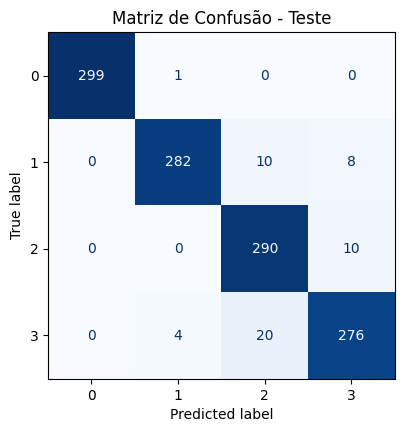

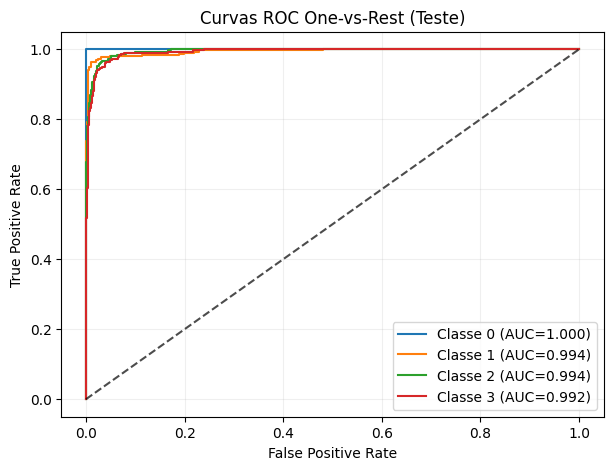

AUC por classe:
Classe 0: 1.0000
Classe 1: 0.9938
Classe 2: 0.9945
Classe 3: 0.9924
AUC macro OvR: 0.9952
AUC weighted OvR: 0.9952


In [7]:
test_loader = make_loader(X_test_scaled, y_test_np, batch_size=256, shuffle=False)

model.eval()
all_probs = []
all_preds = []
all_true = []

with torch.no_grad():
    for xb, yb in test_loader:
        xb = xb.to(device)
        logits = model(xb)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        preds = probs.argmax(axis=1)

        all_probs.append(probs)
        all_preds.append(preds)
        all_true.append(yb.numpy())

y_true = np.concatenate(all_true)
y_pred = np.concatenate(all_preds)
y_prob = np.concatenate(all_probs)

# 1) Acurácia
acc_test = accuracy_score(y_true, y_pred)

# 2) Precisão, recall e F1
prec_macro, rec_macro, f1_macro, _ = precision_recall_fscore_support(
    y_true, y_pred, average="macro", zero_division=0
)
prec_weighted, rec_weighted, f1_weighted, _ = precision_recall_fscore_support(
    y_true, y_pred, average="weighted", zero_division=0
)

print(f"Acurácia (teste - métrica principal): {acc_test:.4f}")
print(f"Precisão macro: {prec_macro:.4f}")
print(f"Recall macro: {rec_macro:.4f}")
print(f"F1 macro: {f1_macro:.4f}")
print(f"F1 weighted: {f1_weighted:.4f}")

print("\nRelatório de classificação:")
print(classification_report(y_true, y_pred, digits=4, zero_division=0))

# 3) Matriz de confusão
cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2, 3])
fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1, 2, 3]).plot(
    cmap="Blues", ax=ax, colorbar=False
)
plt.title("Matriz de Confusão - Teste")
plt.grid(False)
plt.show()

# 4) ROC e AUC multiclasse (OvR)
classes = np.array([0, 1, 2, 3])
y_true_bin = label_binarize(y_true, classes=classes)

auc_per_class = {}
plt.figure(figsize=(7, 5))
for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], y_prob[:, i])
    class_auc = auc(fpr, tpr)
    auc_per_class[int(cls)] = class_auc
    plt.plot(fpr, tpr, label=f"Classe {cls} (AUC={class_auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", alpha=0.7)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC One-vs-Rest (Teste)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()

auc_macro_ovr = roc_auc_score(y_true_bin, y_prob, average="macro", multi_class="ovr")
auc_weighted_ovr = roc_auc_score(y_true_bin, y_prob, average="weighted", multi_class="ovr")

print("AUC por classe:")
for cls, v in auc_per_class.items():
    print(f"Classe {cls}: {v:.4f}")
print(f"AUC macro OvR: {auc_macro_ovr:.4f}")
print(f"AUC weighted OvR: {auc_weighted_ovr:.4f}")

## 6) Conclusão crítica

A análise abaixo é preenchida automaticamente com os resultados obtidos no treino e no teste para apoiar a discussão final (qualidade do treinamento, overfitting/underfitting e possíveis melhorias).

In [8]:
final_train_acc = history["train_acc"][-1]
final_val_acc = history["val_acc"][-1]
acc_gap = final_train_acc - final_val_acc

if acc_gap > 0.08:
    fit_status = "Há indícios de overfitting moderado/alto (gap de acurácia treino-validação elevado)."
elif acc_gap < 0.02 and final_val_acc < 0.70:
    fit_status = "Há indícios de underfitting (baixa acurácia e pouco gap)."
else:
    fit_status = "Treinamento equilibrado, sem sinais severos de overfitting/underfitting."

quality_status = "satisfatório" if acc_test >= 0.80 else "parcialmente satisfatório" if acc_test >= 0.65 else "insatisfatório"

summary_text = f"""
RELATÓRIO FINAL
- Configuração final: lr={best_lr}, batch_size={best_batch_size}, dropout={best_dropout}.
- Melhor val_loss: {best_val_loss:.4f}.
- Acurácia final treino: {final_train_acc:.4f}.
- Acurácia final validação: {final_val_acc:.4f}.
- Gap treino-validação: {acc_gap:.4f}.
- Acurácia de teste (métrica principal): {acc_test:.4f}.
- F1 macro: {f1_macro:.4f}.
- AUC macro OvR: {auc_macro_ovr:.4f}.

ANÁLISE CRÍTICA
- Qualidade do treinamento: {quality_status}.
- Diagnóstico de ajuste: {fit_status}
- Como foi tratado overfitting: uso de Dropout, BatchNorm, EarlyStopping e scheduler de learning rate.
- Interpretação geral: uma Acurácia alta e consistente, acompanhada por AUC macro alto, em um cenário balanceado garante que o modelo generaliza bem para dados não vistos e as classes estão bem separadas.
"""

print(summary_text)


RELATÓRIO FINAL
- Configuração final: lr=0.001, batch_size=128, dropout=0.2.
- Melhor val_loss: 0.1280.
- Acurácia final treino: 0.9270.
- Acurácia final validação: 0.9500.
- Gap treino-validação: -0.0230.
- Acurácia de teste (métrica principal): 0.9558.
- F1 macro: 0.9560.
- AUC macro OvR: 0.9952.

ANÁLISE CRÍTICA
- Qualidade do treinamento: satisfatório.
- Diagnóstico de ajuste: Treinamento equilibrado, sem sinais severos de overfitting/underfitting.
- Como foi tratado overfitting: uso de Dropout, BatchNorm, EarlyStopping e scheduler de learning rate.
- Interpretação geral: uma Acurácia alta e consistente, acompanhada por AUC macro alto, em um cenário balanceado garante que o modelo generaliza bem para dados não vistos e as classes estão bem separadas.



## Portabilidade para o pipeline SMTP

A atividade original foi mantida como referência de exploração, mas a execução reprodutível do treinamento passa a ser feita pela estrutura modular em `smtp`. Nesta etapa, o notebook funciona como ponto de partida para disparar e comparar experimentos rastreados no MLflow.

In [ ]:
from pathlib import Path
import subprocess
import sys

repo_root = Path.cwd().resolve()
while repo_root != repo_root.parent and not (repo_root / "smtp").exists():
    repo_root = repo_root.parent

smtp_dir = repo_root / "smtp"
experimentos = [
    "experimentos/classificacao_default.yaml",
    "experimentos/classificacao_tunada.yaml",
]

for config in experimentos:
    command = [sys.executable, "-m", "mlflow", "run", ".", "--env-manager", "local", "-P", f"config={config}"]
    print(f"Executando: {' '.join(command)}")
    subprocess.run(command, cwd=smtp_dir, check=True)